# NLP EDA on Cleaned Reddit Text
This notebook performs foundational NLP EDA on the cleaned dataset, generates quality and subgroup diagnostics, and writes reusable artifacts for downstream tasks.

In [12]:
from pathlib import Path
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [13]:
# Resolve project paths and load cleaned dataset.
cwd = Path.cwd().resolve()
if (cwd / "Data").exists() or (cwd / "data").exists():
    project_root = cwd
elif (cwd.parent / "Data").exists() or (cwd.parent / "data").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError("Could not find Data/ or data/ from current working directory.")

data_dir = project_root / "Data" if (project_root / "Data").exists() else project_root / "data"
processed_dir = data_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir = processed_dir / "eda_artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

input_path = processed_dir / "reddit_mh_clean.parquet"
if not input_path.exists():
    raise FileNotFoundError(f"Input file not found: {input_path}")

df = pd.read_parquet(input_path)
print(f"Loaded shape: {df.shape}")
print(f"Input file: {input_path}")

required_columns = ["clean_text", "subreddit", "timeframe", "is_mental_health", "covid_period"]
missing_required = [c for c in required_columns if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

# Capture null count BEFORE fillna to ensure accurate reporting
null_clean_text_count = int(df["clean_text"].isna().sum())

df.head(2)

Loaded shape: (1107302, 357)
Input file: /Users/ganenthraravindran/Desktop/Mental Health/Data/processed/reddit_mh_clean.parquet


,subreddit,author,date,post,automated_readability_index,coleman_liau_index,flesch_kincaid_grade_level,flesch_reading_ease,gulpease_index,gunning_fog_index,lix,smog_index,wiener_sachtextformel,n_chars,n_long_words,n_monosyllable_words,n_polysyllable_words,n_sents,n_syllables,n_unique_words,n_words,sent_neg,sent_neu,sent_pos,sent_compound,economic_stress_total,isolation_total,substance_use_total,guns_total,domestic_stress_total,suicidality_total,punctuation,liwc_1st_pers,liwc_2nd_pers,liwc_3rd_pers,liwc_achievement,liwc_adverbs,liwc_affective_processes,liwc_anger,liwc_anxiety,liwc_articles_article,liwc_assent,liwc_auxiliary_verbs,liwc_biological,liwc_body,liwc_causation,liwc_certainty,liwc_cognitive,liwc_common_verbs,liwc_conjunctions,liwc_death,liwc_discrepancy,liwc_exclusive,liwc_family,liwc_feel,liwc_fillers,liwc_friends,liwc_future_tense,liwc_health,liwc_hear,...,tfidf_sorri,tfidf_start,tfidf_stay,tfidf_still,tfidf_stop,tfidf_stress,tfidf_struggl,tfidf_stuff,tfidf_suicid,tfidf_support,tfidf_sure,tfidf_symptom,tfidf_take,tfidf_talk,tfidf_tell,tfidf_thank,tfidf_therapi,tfidf_therapist,tfidf_thing,tfidf_think,tfidf_though,tfidf_thought,tfidf_time,tfidf_tire,tfidf_today,tfidf_told,tfidf_took,tfidf_tri,tfidf_turn,tfidf_two,tfidf_understand,tfidf_us,tfidf_use,tfidf_usual,tfidf_veri,tfidf_want,tfidf_way,tfidf_week,tfidf_weight,tfidf_well,tfidf_went,tfidf_whi,tfidf_whole,tfidf_wish,tfidf_without,tfidf_wonder,tfidf_work,tfidf_worri,tfidf_wors,tfidf_would,tfidf_wrong,tfidf_x200b,tfidf_year,timeframe,is_mental_health,covid_period,clean_text,tokens,clean_word_count,source_text_col
0,COVID19_support,thatreddittherapist,2020/02/15,"Welcome to COVID19 Support! Hi everyone,\n\nI'...",9.341417,9.238381,8.578618,67.262223,59.609756,11.959475,39.654784,11.362044,4.775402,1113,51,175,27,13,350,134,246,0.090,0.720,0.190,0.9807,0,2,0,0,0,1,27.0,1,1,0,3,10,15,0,0,15,0,15,5,1,2,1,42,33,15,0,4,3,0,1,1,0,2,4,0,...,0.0,0.0,0.0,0.064967,0.0,0.0,0.0,0.0,0.0,0.5539,0.0,0.0,0.000000,0.0,0.0,0.074898,0.186065,0.0,0.0,0.0,0.0,0.0,0.094873,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.067124,0.047983,0.0,0.065255,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.059225,0.082616,0.0,0.0,0.0,0.0,0.000000,post,0,1,welcome covid support hi everyone counselor mo...,"[welcome, covid, support, hi, everyone, counse...",110,post
1,COVID19_support,daisy7895528,2020/02/20,Deadman Walking I have Type 2 diabetes and am ...,10.375234,14.460109,7.220383,62.353939,60.869159,11.382804,41.541121,11.003577,6.271984,601,33,68,19,10,169,83,107,0.138,0.774,0.088,-0.7425,0,0,0,0,0,0,63.0,0,0,0,0,4,4,1,0,3,0,6,7,2,1,1,9,10,6,3,1,2,0,2,3,0,1,5,0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.295872,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.428027,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.176907,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.126704,post,0,1,deadman walking type diabetes mid feel like vi...,"[deadman, walking, type, diabetes, mid, feel, ...",46,post


In [14]:
# Data integrity checks + foundational NLP feature diagnostics.
def to_token_list(value):
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        out = []
        for x in value:
            s = str(x).strip().lower()
            if s:
                out.append(s)
        return out
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple)):
                    return [str(x).strip().lower() for x in parsed if str(x).strip()]
            except (ValueError, SyntaxError):
                pass
        return re.findall(r"[a-z]+(?:'[a-z]+)?", s.lower())
    return []

def count_negations(tokens):
    """Count negation tokens, including common contractions."""
    negation_words = {"no", "nor", "not", "never"}
    count = 0
    for token in tokens:
        if token in negation_words:
            count += 1
        # Check for negation contractions (n't suffix)
        elif token.endswith("n't"):
            count += 1
    return count

df["clean_text"] = df["clean_text"].fillna("").astype(str).str.strip()
if "tokens" in df.columns:
    df["tokens_norm"] = df["tokens"].apply(to_token_list)
else:
    df["tokens_norm"] = df["clean_text"].apply(to_token_list)

# Fallback to clean_text tokenization where token parsing yields empty lists.
empty_mask = df["tokens_norm"].str.len() == 0
df.loc[empty_mask, "tokens_norm"] = df.loc[empty_mask, "clean_text"].apply(
    lambda s: re.findall(r"[a-z]+(?:'[a-z]+)?", s.lower())
)

df["char_count_clean"] = df["clean_text"].str.len()
df["token_count_clean"] = df["tokens_norm"].str.len()
df["unique_token_count"] = df["tokens_norm"].apply(lambda x: len(set(x)))
# Type-Token Ratio computed on lowercased tokens (reduces apparent diversity vs. case-sensitive counts)
df["type_token_ratio"] = np.where(df["token_count_clean"] > 0, df["unique_token_count"] / df["token_count_clean"], 0.0)
df["avg_token_length"] = df["tokens_norm"].apply(lambda x: float(np.mean([len(t) for t in x])) if x else 0.0)
df["negation_count"] = df["tokens_norm"].apply(count_negations)

dup_subset_candidates = ["clean_text", "subreddit", "timeframe", "author", "date"]
dup_subset = [c for c in dup_subset_candidates if c in df.columns]
duplicate_rows = int(df[dup_subset].duplicated().sum()) if dup_subset else int(df["clean_text"].duplicated().sum())

# Quality summary with accurate null count (captured before fillna)
quality_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "duplicate_rows",
            "duplicate_clean_text",
            "null_clean_text",
            "empty_clean_text",
            "empty_token_rows",
        ],
        "value": [
            len(df),
            df.shape[1],
            duplicate_rows,
            int(df["clean_text"].duplicated().sum()),
            null_clean_text_count,  # Use captured value from data loading
            int((df["clean_text"] == "").sum()),
            int((df["token_count_clean"] == 0).sum()),
        ],
    }
)

feature_cols = [
    "char_count_clean",
    "token_count_clean",
    "unique_token_count",
    "type_token_ratio",
    "avg_token_length",
    "negation_count",
]

feature_summary = df[feature_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

print("Quality Summary")
print(f"Notes: null_clean_text = {null_clean_text_count} (captured before fillna)")
print(f"       duplicate_rows = duplicates across [clean_text, subreddit, timeframe, author, date]")
print(f"       duplicate_clean_text = duplicates by text only")
display(quality_summary)
print("Feature Summary")
display(feature_summary)

Quality Summary
Notes: null_clean_text = 0 (captured before fillna)
       duplicate_rows = duplicates across [clean_text, subreddit, timeframe, author, date]
       duplicate_clean_text = duplicates by text only


,metric,value
0,rows,1107302
1,columns,364
2,duplicate_rows,0
3,duplicate_clean_text,86311
4,null_clean_text,0
5,empty_clean_text,19
6,empty_token_rows,19


Feature Summary


,count,mean,std,min,50%,75%,90%,95%,99%,max
char_count_clean,1107302.0,553.381390,562.497640,0.0,396.00000,711.000000,1177.000000,1576.000000,2675.000000,30943.000000
token_count_clean,1107302.0,84.870850,85.493032,0.0,61.00000,109.000000,180.000000,241.000000,408.000000,4001.000000
unique_token_count,1107302.0,63.214416,53.753667,0.0,49.00000,83.000000,130.000000,166.000000,257.000000,1224.000000
type_token_ratio,1107302.0,0.809116,0.106246,0.0,0.80916,0.880000,0.954545,1.000000,1.000000,1.000000
avg_token_length,1107302.0,5.518557,1.787678,0.0,5.50000,5.802885,6.132353,6.369565,6.956522,1718.111111
negation_count,1107302.0,2.934319,5.616843,0.0,2.00000,4.000000,7.000000,11.000000,19.000000,4001.000000


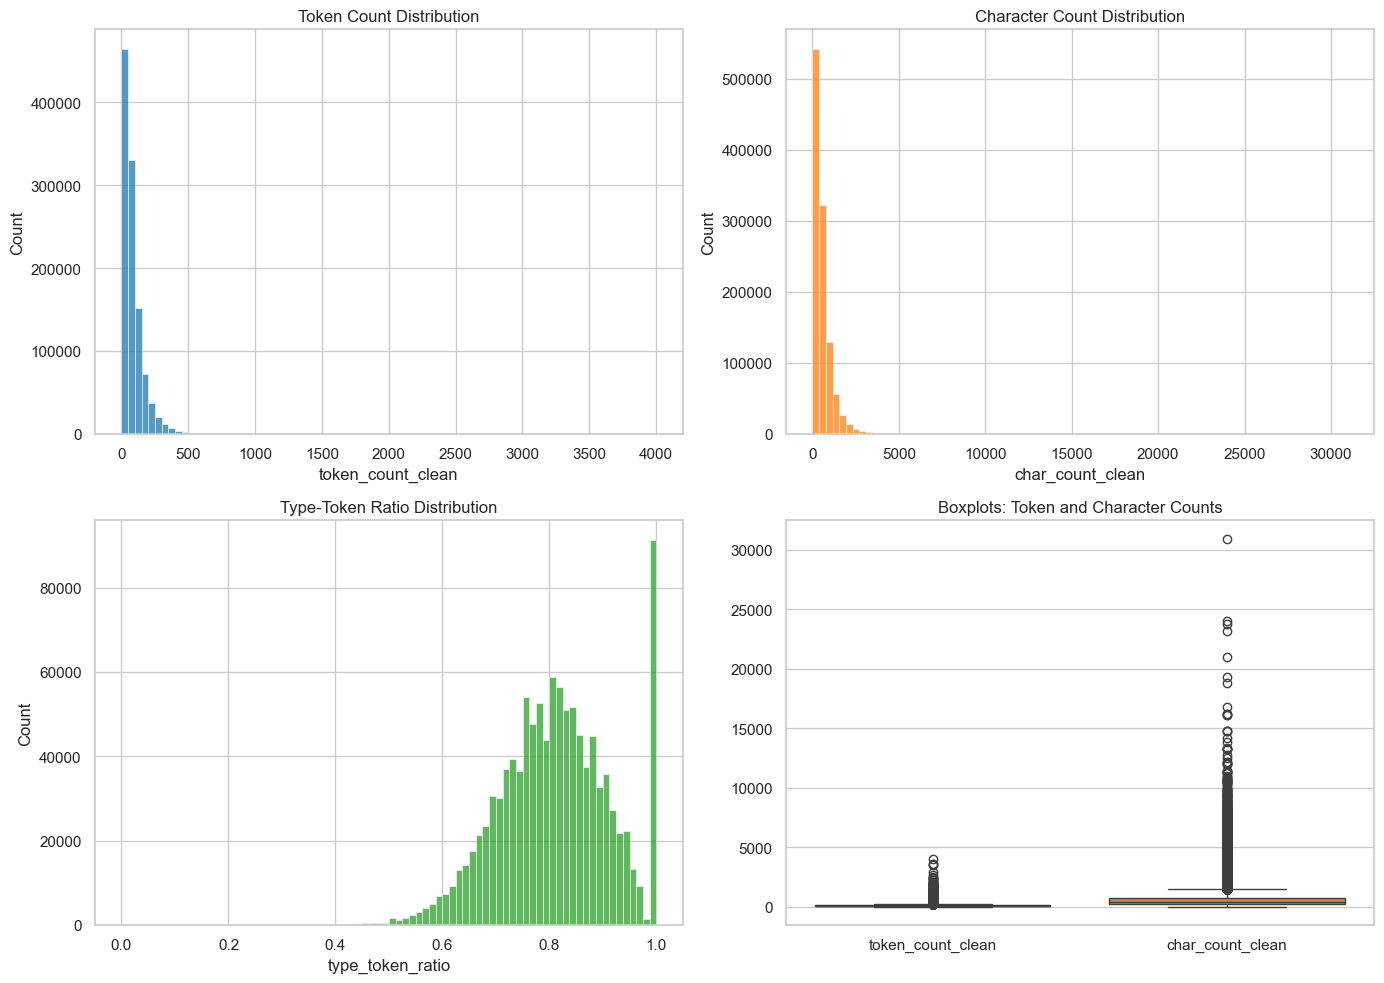

In [15]:
# Global distributions for cleaned-text metrics.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["token_count_clean"], bins=80, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Token Count Distribution")

sns.histplot(df["char_count_clean"], bins=80, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].set_title("Character Count Distribution")

sns.histplot(df["type_token_ratio"], bins=80, ax=axes[1, 0], color="#2ca02c")
axes[1, 0].set_title("Type-Token Ratio Distribution")

sns.boxplot(data=df[["token_count_clean", "char_count_clean"]], ax=axes[1, 1], palette=["#1f77b4", "#ff7f0e"])
axes[1, 1].set_title("Boxplots: Token and Character Counts")

plt.tight_layout()
plt.show()

,is_mental_health,covid_period,timeframe,token_count_clean_count,token_count_clean_mean,token_count_clean_median,token_count_clean_std,char_count_clean_count,char_count_clean_mean,char_count_clean_median,char_count_clean_std,type_token_ratio_count,type_token_ratio_mean,type_token_ratio_median,type_token_ratio_std,negation_count_count,negation_count_mean,negation_count_median,negation_count_std
0,0,0,2018,113879,91.240150,67.0,89.441064,113879,596.373221,437.0,589.578653,113879,0.792224,0.784810,0.114968,113879,3.078285,2.0,4.297288
1,0,0,2019,178264,88.750909,64.0,88.381381,178264,577.034000,418.0,577.866197,178264,0.793515,0.788079,0.114048,178264,2.818915,1.0,4.015058
2,0,0,pre,161263,81.172910,57.0,84.872990,161263,527.711843,368.0,557.978770,161263,0.805076,0.804124,0.110256,161263,2.446494,1.0,3.741372
3,0,1,post,182064,81.621298,59.0,82.999562,182064,534.374890,385.0,548.293735,182064,0.800955,0.797101,0.112126,182064,2.528754,1.0,3.729693
4,1,0,2018,63210,91.456953,66.0,88.603405,63210,597.606012,429.0,582.774648,63210,0.818663,0.821053,0.094235,63210,3.914586,2.0,4.860007
5,1,0,2019,104296,86.799005,62.0,86.073494,104296,564.987564,405.0,564.375464,104296,0.822104,0.824561,0.094692,104296,3.363782,2.0,4.460467
6,1,0,pre,166026,82.214225,59.0,83.385793,166026,536.879742,382.0,551.960173,166026,0.825340,0.827586,0.094914,166026,3.063544,2.0,10.662634
7,1,1,post,138300,81.939725,59.0,82.170102,138300,533.290709,381.0,539.897120,138300,0.824956,0.827586,0.094759,138300,3.140217,2.0,4.304254


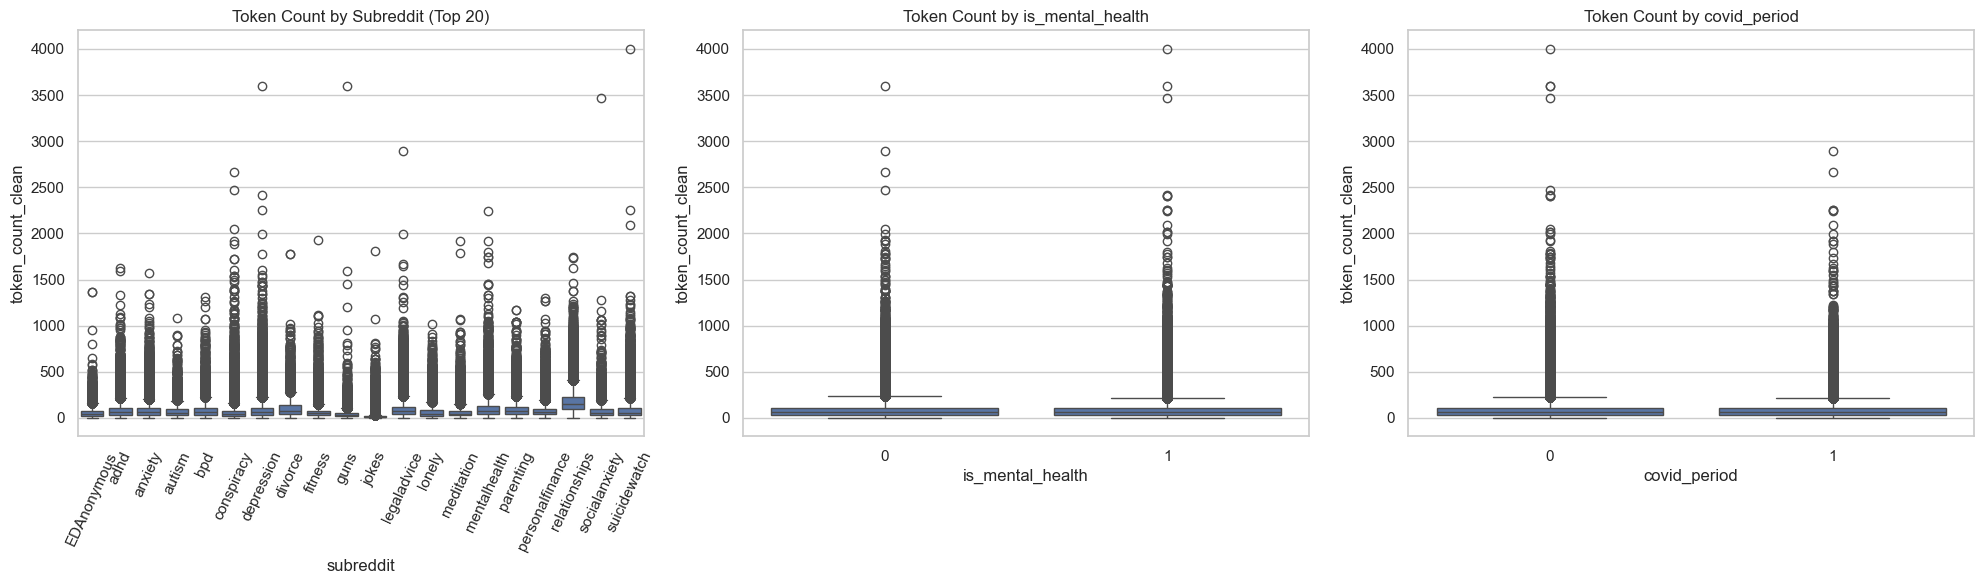

In [16]:
# Subgroup EDA across labels and periods.
group_cols = ["is_mental_health", "covid_period", "timeframe"]
group_metrics = ["token_count_clean", "char_count_clean", "type_token_ratio", "negation_count"]

subgroup_summary = (
    df.groupby(group_cols, dropna=False)[group_metrics]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

subgroup_summary.columns = ["_".join(col).strip("_") for col in subgroup_summary.columns.values]
display(subgroup_summary.head(20))

top_subreddits = df["subreddit"].value_counts().head(20).index
plot_df = df[df["subreddit"].isin(top_subreddits)].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.boxplot(data=plot_df, x="subreddit", y="token_count_clean", ax=axes[0])
axes[0].set_title("Token Count by Subreddit (Top 20)")
axes[0].tick_params(axis="x", rotation=65)

sns.boxplot(data=df, x="is_mental_health", y="token_count_clean", ax=axes[1])
axes[1].set_title("Token Count by is_mental_health")

sns.boxplot(data=df, x="covid_period", y="token_count_clean", ax=axes[2])
axes[2].set_title("Token Count by covid_period")

plt.tight_layout()
plt.show()

In [17]:
# Save EDA artifacts and a downstream-friendly stratified sample.
quality_path = artifacts_dir / "quality_summary.csv"
feature_summary_path = artifacts_dir / "feature_summary.csv"
subgroup_summary_path = artifacts_dir / "subgroup_summary.csv"

# Consistent CSV export: all use index=False for uniform downstream processing
quality_summary.to_csv(quality_path, index=False)
feature_summary.to_csv(feature_summary_path, index=False)
subgroup_summary.to_csv(subgroup_summary_path, index=False)

target_n = min(50_000, len(df))
strata_cols = [c for c in ["is_mental_health", "covid_period", "timeframe"] if c in df.columns]

if strata_cols and target_n < len(df):
    frac = target_n / len(df)
    sampled = (
        df.groupby(strata_cols, group_keys=False)
        .apply(lambda g: g.sample(n=max(1, int(round(len(g) * frac))), random_state=42))
    )
    if len(sampled) > target_n:
        sampled = sampled.sample(n=target_n, random_state=42)
    elif len(sampled) < target_n:
        # Fill remainder to ensure exact target_n size
        remainder = df.drop(index=sampled.index, errors="ignore")
        shortfall = target_n - len(sampled)
        available = len(remainder)
        if available < shortfall:
            raise ValueError(
                f"Cannot achieve target_n={target_n}: only {available} rows available to fill shortfall of {shortfall}"
            )
        fill_n = shortfall
        sampled = pd.concat([sampled, remainder.sample(n=fill_n, random_state=42)], ignore_index=True)
    df_sample = sampled.reset_index(drop=True)
else:
    df_sample = df.sample(n=target_n, random_state=42).reset_index(drop=True)

sample_out_path = processed_dir / "reddit_mh_clean_sample_50000.parquet"
df_sample.to_parquet(sample_out_path, index=False)

print(f"Saved quality summary: {quality_path}")
print(f"Saved feature summary: {feature_summary_path}")
print(f"Saved subgroup summary: {subgroup_summary_path}")
print(f"Saved downstream sample: {sample_out_path}")
print(f"Sample shape: {df_sample.shape}")
assert len(df_sample) == target_n, f"Sample size mismatch: got {len(df_sample)}, expected {target_n}"
df_sample.head()

Saved quality summary: /Users/ganenthraravindran/Desktop/Mental Health/Data/processed/eda_artifacts/quality_summary.csv
Saved feature summary: /Users/ganenthraravindran/Desktop/Mental Health/Data/processed/eda_artifacts/feature_summary.csv
Saved subgroup summary: /Users/ganenthraravindran/Desktop/Mental Health/Data/processed/eda_artifacts/subgroup_summary.csv
Saved downstream sample: /Users/ganenthraravindran/Desktop/Mental Health/Data/processed/reddit_mh_clean_sample_50000.parquet
Sample shape: (50000, 364)


,subreddit,author,date,post,automated_readability_index,coleman_liau_index,flesch_kincaid_grade_level,flesch_reading_ease,gulpease_index,gunning_fog_index,lix,smog_index,wiener_sachtextformel,n_chars,n_long_words,n_monosyllable_words,n_polysyllable_words,n_sents,n_syllables,n_unique_words,n_words,sent_neg,sent_neu,sent_pos,sent_compound,economic_stress_total,isolation_total,substance_use_total,guns_total,domestic_stress_total,suicidality_total,punctuation,liwc_1st_pers,liwc_2nd_pers,liwc_3rd_pers,liwc_achievement,liwc_adverbs,liwc_affective_processes,liwc_anger,liwc_anxiety,liwc_articles_article,liwc_assent,liwc_auxiliary_verbs,liwc_biological,liwc_body,liwc_causation,liwc_certainty,liwc_cognitive,liwc_common_verbs,liwc_conjunctions,liwc_death,liwc_discrepancy,liwc_exclusive,liwc_family,liwc_feel,liwc_fillers,liwc_friends,liwc_future_tense,liwc_health,liwc_hear,...,tfidf_stuff,tfidf_suicid,tfidf_support,tfidf_sure,tfidf_symptom,tfidf_take,tfidf_talk,tfidf_tell,tfidf_thank,tfidf_therapi,tfidf_therapist,tfidf_thing,tfidf_think,tfidf_though,tfidf_thought,tfidf_time,tfidf_tire,tfidf_today,tfidf_told,tfidf_took,tfidf_tri,tfidf_turn,tfidf_two,tfidf_understand,tfidf_us,tfidf_use,tfidf_usual,tfidf_veri,tfidf_want,tfidf_way,tfidf_week,tfidf_weight,tfidf_well,tfidf_went,tfidf_whi,tfidf_whole,tfidf_wish,tfidf_without,tfidf_wonder,tfidf_work,tfidf_worri,tfidf_wors,tfidf_would,tfidf_wrong,tfidf_x200b,tfidf_year,clean_text,tokens,clean_word_count,source_text_col,tokens_norm,char_count_clean,token_count_clean,unique_token_count,type_token_ratio,avg_token_length,negation_count,timeframe,is_mental_health,covid_period
0,legaladvice,KindaSpooked123,2018/01/02,DotA player turned stalker? So. This is kind o...,2.592278,4.961995,3.472824,88.112267,78.465649,5.557487,29.160893,6.671995,1.477495,528,25,102,5,13,168,89,131,0.110,0.848,0.042,-0.8361,1,0,1,1,0,0,15.0,1,0,0,0,9,5,1,0,5,0,14,0,0,1,0,11,19,11,0,1,1,0,2,1,0,2,0,0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.189409,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.223372,0.000000,0.000000,0.0,0.256323,0.000000,0.0,0.000000,0.203529,0.0,0.0,0.000000,0.374101,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,dota player turned stalker kind spooky today p...,"[dota, player, turned, stalker, kind, spooky, ...",59,post,"[dota, player, turned, stalker, kind, spooky, ...",398,59,53,0.898305,5.762712,0,NaN,NaN,NaN
1,personalfinance,Ihavealpacas,2018/02/03,Shopping for Car insurance. Questions about ho...,1.112143,3.497218,3.499643,85.556607,84.714286,7.214286,23.750000,8.278500,1.761000,540,21,110,13,16,186,81,140,0.065,0.886,0.049,-0.2505,2,0,0,0,0,0,18.0,1,0,0,1,10,4,0,0,7,0,17,0,0,6,1,27,28,11,0,7,0,0,0,1,0,2,0,0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.100856,0.000000,0.000000,0.0,0.153742,0.0,0.000000,0.190907,0.000000,0.0,0.185434,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,shopping car insurance question much coverage ...,"[shopping, car, insurance, question, much, cov...",62,post,"[shopping, car, insurance, question, much, cov...",407,62,46,0.741935,5.580645,2,NaN,NaN,NaN
2,legaladvice,confusedandcrying,2018/01/17,"Mother passed away, remains possibly weren't a...",8.480617,9.405882,8.407218,64.315940,61.190476,11.837928,39.118630,11.520995,5.107063,1446,71,215,41,19,468,172,315,0.053,0.870,0.076,0.0978,0,0,0,0,0,0,36.0,15,0,4,3,7,11,0,0,10,0,25,6,2,2,1,44,42,15,9,5,3,9,2,0,0,1,4,3,...,0.0,0.0,0.235864,0.0,0.0,0.078138,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.06659,0.0,0.0,0.060599,0.0,0.000000,0.099304,0.115464,0.0,0.000000,0.000000,0.0,0.125008,0.000000,0.0,0.0,0.061297,0.000000,0.083362,0.0,0.000000,0.0,0.000000,0.000000,0.119508,0.0,0.000000,0.0,0.0,0.0,0.073825,0.0,0.0,0.0,mother passed away remains possibly weren't ap...,"[mother, passed, away, remains, possibly, were...",166,post,"[mother, passed, 